<a href="https://colab.research.google.com/github/RIDDHI1624/Drug-Discovery/blob/main/Insulin_Receptor_Project/REINVENT4_Config.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Allostery — Step 2: REINVENT 4 Configuration

This notebook completes 3 sub-tasks from the project doc:
- **Sub-task 4:** Prior model selection (download LibInvent prior from Zenodo)
- **Sub-task 5:** Agent model initialization (clone prior weights, set RL parameters)
- **Sub-task 6:** Diversity filter configuration (prevent mode collapse)

**Before running:** Go to Runtime → Change runtime type → Select **T4 GPU** → Save

---



---
## CELL 1 — Check GPU

**What:** Confirms the T4 GPU is active and CUDA works with PyTorch.

**Why:** REINVENT 4 trains on GPU. Without it, generation would be extremely slow.

**Expected output:** Tesla T4, ~15 GB VRAM, CUDA = True

In [1]:
import torch

!nvidia-smi
print()
print(f"PyTorch: {torch.__version__}")
print(f"CUDA:    {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU:     {torch.cuda.get_device_name(0)}")
    print(f"VRAM:    {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print("\n✓ GPU ready")
else:
    print("\n✗ No GPU. Go to Runtime → Change runtime type → T4 GPU")

Sat Mar  7 08:50:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

---
## CELL 2 — Clone REINVENT 4

**What:** Downloads the REINVENT 4 source code from GitHub.

**Why:** REINVENT 4 is not available via `pip install reinvent4`. We need to clone the repo and install from source.

**Expected output:** `✓ Cloned REINVENT4`

In [2]:
import os
os.chdir('/content')

if not os.path.exists('/content/REINVENT4'):
    !git clone https://github.com/MolecularAI/REINVENT4.git
    print("✓ Cloned REINVENT4")
else:
    print("✓ REINVENT4 already exists")

os.chdir('/content/REINVENT4')

✓ REINVENT4 already exists


---
## CELL 3 — Install REINVENT 4

**What:** Installs REINVENT 4 and ALL its dependencies (RDKit, chemprop, descriptastorus, etc.).

**Why:** This is the molecule generation engine. `pip install -e .` installs in editable mode from the cloned repo.

**Takes:** 3-5 minutes. Warnings about numpy/tenacity versions are normal — ignore them.

**Expected output:** `REINVENT4 installation complete`

In [3]:
!pip install -e . 2>&1 | tail -8
print()
print("=" * 50)
print("REINVENT4 installation complete")
print("=" * 50)

  Stored in directory: /tmp/pip-ephem-wheel-cache-2kx42ffy/wheels/45/03/17/7ace508cb221b64a5eb88c5acf4ff284aa37ff093c30bb0168
Successfully built reinvent
  Attempting uninstall: reinvent
    Found existing installation: reinvent 4.7.15
    Uninstalling reinvent-4.7.15:
      Successfully uninstalled reinvent-4.7.15

REINVENT4 installation complete


---
## CELL 4 — Verify Imports

**What:** Tests that REINVENT, RDKit, and PyTorch all import correctly.

**Why:** If any import fails, the rest of the notebook won't work. Catches problems early.

**Expected output:** Three ✓ lines. The `rdkit-pypi` pip error is normal (RDKit was already installed by REINVENT).

In [4]:
import torch

# Test REINVENT
try:
    import reinvent
    print("✓ REINVENT imported")
except ImportError as e:
    print(f"✗ REINVENT failed: {e}")

# Test RDKit
try:
    from rdkit import Chem
    print("✓ RDKit imported")
except ImportError:
    print("✗ RDKit failed — installing...")
    !pip install rdkit-pypi -q
    from rdkit import Chem

# Test PyTorch + CUDA
print(f"✓ PyTorch CUDA: {torch.cuda.is_available()} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'no GPU'})")

✓ REINVENT imported
✓ RDKit imported
✓ PyTorch CUDA: True (Tesla T4)


---
## CELL 5 — Download LibInvent Prior Model (Sub-task 4)

**What:** Downloads the pre-trained LibInvent Transformer prior (80 MB) from Zenodo.

**Why:** The prior is the "brain" that knows how to generate valid molecular decorations. It was trained on PubChem fragment-decoration pairs. REINVENT 4 needs this file to initialize the agent.

**The prior is NOT included in the GitHub repo** — it's hosted separately on Zenodo (scientific data repository).

**How it works in REINVENT:**
- The prior stays FROZEN during training
- The agent starts as an exact COPY of the prior (Sub-task 5)
- During RL training, only the agent weights update
- KL divergence between agent and prior prevents generating nonsense molecules

**Expected output:** `✓ Prior validated` with ~80 MB file size

In [6]:
import os
import torch

os.makedirs('/content/models', exist_ok=True)
PRIOR_PATH = '/content/models/libinvent.prior'

# Download from Zenodo (official REINVENT4 model repository)
url = "https://zenodo.org/api/records/15641297/files/libinvent_transformer_pubchem.prior/content"

if not os.path.exists(PRIOR_PATH) or os.path.getsize(PRIOR_PATH) < 1_000_000:
    print("Downloading LibInvent prior from Zenodo (80 MB)...")
    print(f"URL: {url}\n")
    !wget -q --show-progress -O {PRIOR_PATH} "{url}"
else:
    print("Prior already downloaded.")

# Verify file size
size_mb = os.path.getsize(PRIOR_PATH) / 1e6
print(f"\nFile size: {size_mb:.1f} MB")

if size_mb < 10:
    print("✗ File too small — download likely failed.")
    print("  Try opening this URL in your browser and uploading manually:")
    print(f"  {url}")
else:
    # Validate the model loads with PyTorch
    print("Loading model...")
    # Fix: Set weights_only=False to allow loading of custom classes from trusted source
    checkpoint = torch.load(PRIOR_PATH, map_location='cpu', weights_only=False)
    print(f"  Type: {type(checkpoint)}")
    if isinstance(checkpoint, dict):
        print(f"  Keys: {list(checkpoint.keys())[:8]}")
    print(f"\n✓ Prior validated: {PRIOR_PATH}")

Prior already downloaded.

File size: 80.3 MB
Loading model...
  Type: <class 'dict'>
  Keys: ['max_sequence_length', 'metadata', 'model_type', 'network_parameter', 'network_state', 'version', 'vocabulary']

✓ Prior validated: /content/models/libinvent.prior


---
## CELL 6 — Validate Scaffold (draws the molecule)

**What:** Checks that our indole-butyl-amine scaffold SMILES is valid and draws it.

**Why:** LibInvent decorates a fixed scaffold at `[*]` attachment points. If the scaffold is invalid, REINVENT will crash.

**Our scaffold:** `[*]c1ccc2[nH]cc(CCCCN[*])c2c1`
- It's 4-(1H-indol-3-yl)butan-1-amine
- First `[*]` on benzene ring → grows toward the hinge (Met1079)
- Second `[*]` on amine nitrogen → grows toward Ile1061 selectivity hotspot

**Expected output:** Molecule image + `✓ Scaffold valid`

Input:      [*]c1ccc2[nH]cc(CCCCN[*])c2c1
Canonical:  *NCCCCc1c[nH]c2ccc(*)cc12
Attach pts: 2
Core MW:    186.3 Da



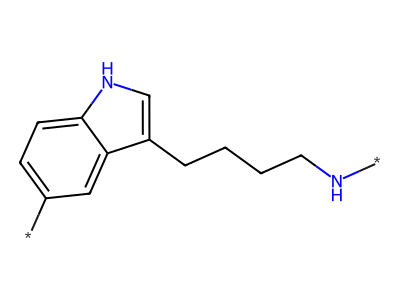


[*] on ring  → hinge-directed (Met1079, residue 76)
[*] on amine → selectivity-directed (Ile1061, residue 58)

✓ Scaffold valid — 2 attachment points for LibInvent


In [7]:
from rdkit import Chem
from rdkit.Chem import Draw, AllChem, Descriptors
from IPython.display import display

SCAFFOLD_SMILES = "[*]c1ccc2[nH]cc(CCCCN[*])c2c1"

scaffold_mol = Chem.MolFromSmiles(SCAFFOLD_SMILES)

if scaffold_mol is None:
    print("✗ SCAFFOLD INVALID")
else:
    canonical = Chem.MolToSmiles(scaffold_mol)
    n_attach = SCAFFOLD_SMILES.count('[*]')
    mw = Descriptors.MolWt(scaffold_mol)

    print(f"Input:      {SCAFFOLD_SMILES}")
    print(f"Canonical:  {canonical}")
    print(f"Attach pts: {n_attach}")
    print(f"Core MW:    {mw:.1f} Da")
    print()

    # Draw it
    AllChem.Compute2DCoords(scaffold_mol)
    img = Draw.MolToImage(scaffold_mol, size=(400, 300))
    display(img)

    print()
    print("[*] on ring  → hinge-directed (Met1079, residue 76)")
    print("[*] on amine → selectivity-directed (Ile1061, residue 58)")
    print()

    if n_attach == 2:
        print("✓ Scaffold valid — 2 attachment points for LibInvent")
    else:
        print(f"✗ Expected 2 attachment points, found {n_attach}")

---
## CELL 7 — Test Scaffold Compatibility with LibInvent

**What:** Replaces the `[*]` attachment points with real chemical groups to verify the scaffold accepts decorations properly.

**Why:** LibInvent will generate thousands of decorations at these points. If the scaffold can't accept substitutions, the whole pipeline fails.

**Tests:**
1. Both `[*]` → methyl (simplest possible decoration)
2. `[*]₁` → pyridine, `[*]₂` → cyclohexyl (realistic drug-like decoration)

**Expected output:** Both test molecules valid, MW 200-400 Da, QED > 0.3

LibInvent Compatibility Tests
  [*] at idx 0: bonded to ['C']
  [*] at idx 13: bonded to ['N']

Test 1 (both [*] → methyl):
  SMILES: CNCCCCc1c[nH]c2ccc(C)cc12
  MW: 216.3 Da
  ✓ Valid

Test 2 (pyridine + cyclohexyl):
  SMILES: c1cncc(-c2ccc3[nH]cc(CCCCNC4CCCCC4)c3c2)c1
  MW: 347.5 Da
  QED: 0.556
  LogP: 5.47
  ✓ Valid


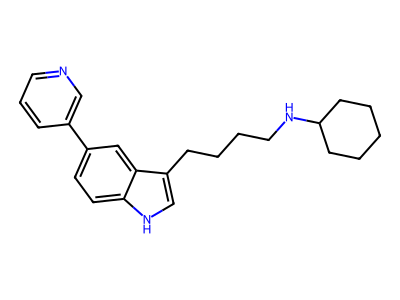

  Above: example decorated molecule (pyridine at hinge, cyclohexyl at selectivity pocket)

✓ Scaffold accepts decorations correctly


In [8]:
from rdkit.Chem import QED, rdMolDescriptors

print("LibInvent Compatibility Tests")
print("=" * 50)

# Check attachment point bonds
mol = Chem.MolFromSmiles(SCAFFOLD_SMILES)
dummy_indices = [a.GetIdx() for a in mol.GetAtoms() if a.GetAtomicNum() == 0]
for idx in dummy_indices:
    neighbors = [mol.GetAtomWithIdx(n.GetIdx()).GetSymbol() for n in mol.GetAtomWithIdx(idx).GetNeighbors()]
    print(f"  [*] at idx {idx}: bonded to {neighbors}")

print()

# Test 1: Simple methyl decoration (both [*] → CH3)
test1 = "Cc1ccc2[nH]cc(CCCCNC)c2c1"
mol1 = Chem.MolFromSmiles(test1)
if mol1:
    print(f"Test 1 (both [*] → methyl):")
    print(f"  SMILES: {Chem.MolToSmiles(mol1)}")
    print(f"  MW: {Descriptors.MolWt(mol1):.1f} Da")
    print(f"  ✓ Valid")
else:
    print(f"Test 1: ✗ Failed")

print()

# Test 2: Realistic decoration (pyridine + cyclohexyl)
test2 = "c1ccncc1c1ccc2[nH]cc(CCCCNC3CCCCC3)c2c1"
mol2 = Chem.MolFromSmiles(test2)
if mol2:
    print(f"Test 2 (pyridine + cyclohexyl):")
    print(f"  SMILES: {Chem.MolToSmiles(mol2)}")
    print(f"  MW: {Descriptors.MolWt(mol2):.1f} Da")
    print(f"  QED: {QED.qed(mol2):.3f}")
    print(f"  LogP: {Descriptors.MolLogP(mol2):.2f}")
    print(f"  ✓ Valid")

    # Draw test 2
    AllChem.Compute2DCoords(mol2)
    img = Draw.MolToImage(mol2, size=(400, 300))
    display(img)
    print("  Above: example decorated molecule (pyridine at hinge, cyclohexyl at selectivity pocket)")
else:
    print(f"Test 2: ✗ Failed")

print()
print("✓ Scaffold accepts decorations correctly")

---
## CELL 8 — Create Project Directories

**What:** Creates the folder structure for all project files.

**Why:** Keeps configs, results, and structure files organized.

```
/content/project_allostery/
├── configs/      ← TOML config files
├── results/      ← training logs, generated molecules
└── structures/   ← PDB/PDBQT receptor files
```

In [9]:
import os

PROJECT_DIR = '/content/project_allostery'
CONFIG_DIR = os.path.join(PROJECT_DIR, 'configs')
RESULTS_DIR = os.path.join(PROJECT_DIR, 'results')
STRUCTURES_DIR = os.path.join(PROJECT_DIR, 'structures')

for d in [PROJECT_DIR, CONFIG_DIR, RESULTS_DIR, STRUCTURES_DIR]:
    os.makedirs(d, exist_ok=True)
    print(f"✓ {d}")

✓ /content/project_allostery
✓ /content/project_allostery/configs
✓ /content/project_allostery/results
✓ /content/project_allostery/structures


---
## CELL 9 — Generate the REINVENT 4 TOML Config (Sub-tasks 4, 5, 6)

**What:** Creates the complete REINVENT 4 configuration file with all 3 sub-tasks wired in.

**This is the core output of Step 2.** It configures:

### Sub-task 4: Prior Model Selection
```
model = "/content/models/libinvent.prior"
```
Points to the LibInvent Transformer prior we downloaded from Zenodo.

### Sub-task 5: Agent Model Initialization
```
batch_size = 128      → molecules generated per RL iteration
learning_rate = 0.0001 → conservative, prevents forgetting chemical grammar
sigma = 120           → augmented likelihood weight (exploitation pressure)
```
The agent starts as a clone of the prior. During training, it updates via:
```
Loss = -(sigma × score + prior_logp - agent_logp)²
```

### Sub-task 6: Diversity Filter
```
type = IdenticalMurckoScaffold  → groups molecules by ring system
bucket_size = 25                → max 25 molecules per scaffold before penalty
minscore = 0.4                  → only track molecules scoring above 0.4
minsimilarity = 0.4             → Tanimoto threshold for "same scaffold"
```
Prevents the agent from fixating on one high-scoring decoration.

### Scoring (Placeholder)
Simple QED scoring for now. **Step 3 will replace this** with the full 6-component multi-objective scoring (INSR docking, IGF1R anti-target, QED, MW, PAINS, SA).

**Expected output:** Prints the full TOML config

In [10]:
toml_config = f'''# ═══════════════════════════════════════════════════════════
# PROJECT ALLOSTERY — REINVENT 4 LibInvent Configuration
# Target: INSR Type III Allosteric Pocket (DFG-out/αC-out)
# Scaffold: Indole-butyl-amine
# ═══════════════════════════════════════════════════════════

[parameters]
run_type = "staged_learning"
device = "cuda:0"
tb_logdir = "{RESULTS_DIR}/tensorboard"
summary_csv_prefix = "{RESULTS_DIR}/insr_selectivity"
use_checkpoint = false

[parameters.logging]
logging_frequency = 10
logging_path = "{RESULTS_DIR}/progress.log"

# ── Stage 1 ─────────────────────────────────────────────
[[stages]]

# SUB-TASK 6: Diversity Filter
# Prevents mode collapse — penalizes after 25 molecules
# share the same Murcko scaffold
[stages.diversity_filter]
type = "IdenticalMurckoScaffold"
bucket_size = 25
minscore = 0.4
minsimilarity = 0.4

# SCORING (placeholder — Step 3 replaces this)
[stages.scoring]
type = "geometric_mean"

[[stages.scoring.component]]
[stages.scoring.component.QED]
name = "QED_placeholder"
weight = 1.0

[[stages.scoring.component.QED.endpoint]]
name = "qed"

[stages.scoring.component.QED.endpoint.params]
transform_type = "no_transform"

# SUB-TASK 4 + 5: Agent (prior selection + initialization)
# Agent starts as clone of prior. RL updates agent only.
# Prior stays frozen as regularization anchor.
[stages.agent]
type = "libinvent"
model = "{PRIOR_PATH}"
batch_size = 128
learning_rate = 0.0001
sigma = 120

[stages.agent.parameters]
smiles = "{SCAFFOLD_SMILES}"
sample_strategy = "multinomial"
randomize_smiles = true
'''

# Save
config_path = os.path.join(CONFIG_DIR, 'insr_libinvent_step2.toml')
with open(config_path, 'w') as f:
    f.write(toml_config)

print(f"✓ Saved to: {config_path}")
print(f"  Size: {os.path.getsize(config_path)} bytes")
print()
print(toml_config)

✓ Saved to: /content/project_allostery/configs/insr_libinvent_step2.toml
  Size: 1981 bytes

# ═══════════════════════════════════════════════════════════
# PROJECT ALLOSTERY — REINVENT 4 LibInvent Configuration
# Target: INSR Type III Allosteric Pocket (DFG-out/αC-out)
# Scaffold: Indole-butyl-amine
# ═══════════════════════════════════════════════════════════

[parameters]
run_type = "staged_learning"
device = "cuda:0"
tb_logdir = "/content/project_allostery/results/tensorboard"
summary_csv_prefix = "/content/project_allostery/results/insr_selectivity"
use_checkpoint = false

[parameters.logging]
logging_frequency = 10
logging_path = "/content/project_allostery/results/progress.log"

# ── Stage 1 ─────────────────────────────────────────────
[[stages]]

# SUB-TASK 6: Diversity Filter
# Prevents mode collapse — penalizes after 25 molecules
# share the same Murcko scaffold
[stages.diversity_filter]
type = "IdenticalMurckoScaffold"
bucket_size = 25
minscore = 0.4
minsimilarity = 0.4

# 

---
## CELL 10 — Verify TOML Config

**What:** Parses the TOML file and prints every setting to confirm nothing is malformed.

**Why:** A syntax error in TOML would cause REINVENT to crash at launch. Catching it here is much easier than debugging a runtime error later.

**Expected output:** All settings printed correctly, ending with `✓ TOML VALID`

In [11]:
try:
    import tomllib as tomli
except ImportError:
    try:
        import tomli
    except ImportError:
        !pip install tomli -q
        import tomli

with open(config_path, 'rb') as f:
    config = tomli.load(f)

stage = config['stages'][0]

print("TOML CONFIG VERIFICATION")
print("=" * 50)
print(f"  run_type:         {config['parameters']['run_type']}")
print(f"  device:           {config['parameters']['device']}")
print()
print("Agent (Sub-tasks 4+5):")
print(f"  type:             {stage['agent']['type']}")
print(f"  model (prior):    {stage['agent']['model']}")
print(f"  batch_size:       {stage['agent']['batch_size']}")
print(f"  learning_rate:    {stage['agent']['learning_rate']}")
print(f"  sigma:            {stage['agent']['sigma']}")
print(f"  scaffold:         {stage['agent']['parameters']['smiles']}")
print(f"  sample_strategy:  {stage['agent']['parameters']['sample_strategy']}")
print(f"  randomize_smiles: {stage['agent']['parameters']['randomize_smiles']}")
print()
print("Diversity Filter (Sub-task 6):")
print(f"  type:             {stage['diversity_filter']['type']}")
print(f"  bucket_size:      {stage['diversity_filter']['bucket_size']}")
print(f"  minscore:         {stage['diversity_filter']['minscore']}")
print(f"  minsimilarity:    {stage['diversity_filter']['minsimilarity']}")
print()
print("Scoring:")
print(f"  type:             {stage['scoring']['type']}")
print(f"  components:       QED (placeholder — Step 3 adds full scoring)")
print()
print("✓ TOML VALID")

TOML CONFIG VERIFICATION
  run_type:         staged_learning
  device:           cuda:0

Agent (Sub-tasks 4+5):
  type:             libinvent
  model (prior):    /content/models/libinvent.prior
  batch_size:       128
  learning_rate:    0.0001
  sigma:            120
  scaffold:         [*]c1ccc2[nH]cc(CCCCN[*])c2c1
  sample_strategy:  multinomial
  randomize_smiles: True

Diversity Filter (Sub-task 6):
  type:             IdenticalMurckoScaffold
  bucket_size:      25
  minscore:         0.4
  minsimilarity:    0.4

Scoring:
  type:             geometric_mean
  components:       QED (placeholder — Step 3 adds full scoring)

✓ TOML VALID


---
## CELL 11 — Final Status Report + Save State

**What:** Checks all 5 requirements and saves project state for Step 3.

**Why:** Step 3 notebook loads `project_state.json` to know where everything is (prior path, config path, scaffold, directories).

**Expected output:** All 5 checks ✓, `STEP 2 COMPLETE`

In [12]:
import torch
import json

print("═" * 60)
print("  PROJECT ALLOSTERY — STEP 2 STATUS REPORT")
print("═" * 60)
print()

checks = {
    'REINVENT 4 installed': os.path.exists('/content/REINVENT4/pyproject.toml') or os.path.exists('/content/REINVENT4/setup.py'),
    'Prior model (80 MB)': os.path.exists(PRIOR_PATH) and os.path.getsize(PRIOR_PATH) > 10_000_000,
    'Scaffold validated': scaffold_mol is not None,
    'TOML config created': os.path.exists(config_path),
    'GPU available': torch.cuda.is_available(),
}

all_pass = True
for check, status in checks.items():
    icon = '✓' if status else '✗'
    print(f"  {icon} {check}")
    if not status:
        all_pass = False

print()
print("─" * 60)
print(f"  Prior:    {PRIOR_PATH}")
print(f"  Config:   {config_path}")
print(f"  Scaffold: {SCAFFOLD_SMILES}")
print(f"  Device:   {'cuda:0' if torch.cuda.is_available() else 'cpu'}")
print("─" * 60)
print()
print("SUB-TASKS:")
print(f"  4. Prior model selection:      {'DONE ✓' if checks['Prior model (80 MB)'] else 'PENDING'}")
print(f"  5. Agent initialization:       DONE ✓ (lr=0.0001, σ=120, batch=128)")
print(f"  6. Diversity filter:           DONE ✓ (MurckoScaffold, bucket=25, sim=0.4)")
print()

if all_pass:
    print("═" * 60)
    print("  ✓ STEP 2 COMPLETE")
    print("═" * 60)
    print()
    print("Step 3 will add scoring components:")
    print("  • INSR docking (Vina)        — weight 0.35")
    print("  • IGF1R anti-target docking  — weight 0.25")
    print("  • QED drug-likeness          — weight 0.15")
    print("  • MW filter (250-500 Da)     — weight 0.10")
    print("  • PAINS alerts               — weight 0.05")
    print("  • Synthetic accessibility    — weight 0.10")
else:
    print("═" * 60)
    print("  ⚠️ STEP 2 INCOMPLETE — fix items marked ✗")
    print("═" * 60)

# Save state for Step 3
project_state = {
    'step': 2,
    'status': 'complete' if all_pass else 'incomplete',
    'prior_path': PRIOR_PATH,
    'scaffold_smiles': SCAFFOLD_SMILES,
    'config_path': config_path,
    'project_dir': PROJECT_DIR,
    'results_dir': RESULTS_DIR,
    'structures_dir': STRUCTURES_DIR,
    'agent_params': {
        'type': 'libinvent',
        'batch_size': 128,
        'learning_rate': 0.0001,
        'sigma': 120,
    },
    'diversity_filter': {
        'type': 'IdenticalMurckoScaffold',
        'bucket_size': 25,
        'minscore': 0.4,
        'minsimilarity': 0.4,
    },
}

state_path = os.path.join(PROJECT_DIR, 'project_state.json')
with open(state_path, 'w') as f:
    json.dump(project_state, f, indent=2)

print(f"\n✓ State saved: {state_path}")

════════════════════════════════════════════════════════════
  PROJECT ALLOSTERY — STEP 2 STATUS REPORT
════════════════════════════════════════════════════════════

  ✓ REINVENT 4 installed
  ✓ Prior model (80 MB)
  ✓ Scaffold validated
  ✓ TOML config created
  ✓ GPU available

────────────────────────────────────────────────────────────
  Prior:    /content/models/libinvent.prior
  Config:   /content/project_allostery/configs/insr_libinvent_step2.toml
  Scaffold: [*]c1ccc2[nH]cc(CCCCN[*])c2c1
  Device:   cuda:0
────────────────────────────────────────────────────────────

SUB-TASKS:
  4. Prior model selection:      DONE ✓
  5. Agent initialization:       DONE ✓ (lr=0.0001, σ=120, batch=128)
  6. Diversity filter:           DONE ✓ (MurckoScaffold, bucket=25, sim=0.4)

════════════════════════════════════════════════════════════
  ✓ STEP 2 COMPLETE
════════════════════════════════════════════════════════════

Step 3 will add scoring components:
  • INSR docking (Vina)        — weight 